![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Model-Agnostic Interpretation with SHAP

In this Notebook, we will demonstrate how to use the SHapley Additive exPlanations (SHAP) method and interpret its results.

--------

## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. To start working on the notebook, click on the following button. This will open this page in the Colab environment, and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/xai-for-random-forest/Gen-3-Tutorial_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Google Colab, follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
At this point, a folder has been created in your Drive, and you can navigate it through the lefthand panel in Colab. You might also have received an email that informs you about the access on your Google Drive.

In [ ]:
# Mount drive folder to dbe abale to download repo
# from google.colab import drive
# drive.mount('/content/drive')

# Switch to correct folder'
# %cd /content/drive/MyDrive

In [ ]:
# Don't run this cell if you already cloned the repo 
# %rm -r XAI-Tutorials
# !git clone --branch main https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git

In [ ]:
# Install al required dependencies and package versions
# %cd XAI-Tutorials
# !pip install -r requirements_xai-for-random-forest.txt
# %cd xai-for-random-forest

### Imports

Let's start with importing all required Python packages.

In [1]:
import sys
import pickle

import numpy as np
import pandas as pd

import shap

sys.path.append('./')
import utils

Now, we fix the random seeds to ensure reproducible results, as we work with (pseudo) random numbers.

In [2]:
# assert reproducible random number generation
seed = 1
np.random.seed(seed)

--------

## Data and Model Loading: The California Housing Dataset

In this notebook, we will work with the **California Housing dataset**, containing 20,640 median house values for California districts (expressed in $100,000), which are described by 8 numeric feature. Each row in the dataset represents a block of houses, not a single household. The data pertains to the house prices found in a given California district and some summary statistics about them based on the 1990 census data. Our goal is to **predict price** of house blocks and find the most predictive features.

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/dataset_california_housing.jpg?raw=true" width="900" /></center>

<font size=1> Source: [Link](https://www.kaggle.com/datasets/harrywang/housing)

In the notebook [*Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb*](./Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb), we explain how to do the exploratory data analysis, preprocess the data and train a Random Forest model with the given data. The focus of this notebook is the interpretation of the previously trained model.

In [3]:
# Load and unpack the data
with open('../models/model_rf_housing.pickle', 'rb') as handle:
    data_and_model = pickle.load(handle)

X_train = data_and_model[0]
X_test = data_and_model[1]
y_train = data_and_model[2]
y_test = data_and_model[3]
model_housing = data_and_model[4]

# is the model performing reasonably on the training data?
print(f'Model Performance on training data: {round(model_housing.score(X_train, y_train),2)} R^2.')

# is the model performing reasonably on the test data?
print(f'Model Performance on test data: {round(model_housing.score(X_test, y_test),2)} R^2.')

Model Performance on training data: 0.84 R^2.
Model Performance on test data: 0.72 R^2.


As we can see by the numbers above, our model performs well on the training set and also generalizes well to the independent test set.

**You should keep in mind that interpreting a low-performing model can lead to wrong conclusions.**

*Note: The $R^2$ is the coefficient of determination, and the closer this value is to 1, the better our model explains the data. A constant model that always predicts the average target value disregarding the input features would get an $R^2$ score of 0. However, the $R^2$ score can also be negative because the model can be arbitrarily worse.*

## Now, what does my model think is important in the data?

### SHapley Additive exPlanations (SHAP)

**We prepared a small [Introduction to SHAP](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/shap.html) for you, to help you understand how this method works.**

*Note: we provide all references [here](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/shap.html#references).*

<font color='green'>

#### Question 1: What does the Shapley value tell you about the effect of the feature on a prediction?

<font color='grey'>

#### Your Answer:

A Shapley value quantifies how much a specific feature contributes to moving an individual prediction away from the average model prediction. Positive SHAP values increase the prediction, while negative SHAP values decrease it.

<font color='green'>

#### Question 2: What are the differences between the permutation importance method?

<font color='grey'>

#### Your Answer:

* SHAP values explain the contribution of features to individual predictions, while Permutation Feature Importance measures how much overall model performance decreases when a feature is shuffled.
* SHAP is based purely on model predictions and feature contributions, whereas Permutation Feature Importance depends on a chosen performance metric.
* SHAP considers many possible feature combinations to fairly distribute contributions among features.
* SHAP values are additive and always sum up to the difference between the prediction and the average model output. In contrast, Permutation Feature Importance values are independent and do not necessarily sum to the overall model performance.

<font color='green'>

#### Question 3: What is the main limitation of Shapley values and why?

<font color='grey'>

#### Your Answer:

* SHAP can become computationally expensive, especially for large models and datasets with many features, because it is based on evaluating many possible feature combinations.
* Correlated features can make the attribution less straightforward, since contributions may be shared across multiple related features. 

Now let's use SHAP to get insights into the Random Forest Regression model we loaded above. The `shap.Explainer()` function computes the SHAP values for any machine learning model. If your dataset is large, you might want to use a subset of your original training data, as the SHAP value calculation takes some time. Since our model is a Random Forest model, we use TreeSHAP, which calculates Shapley values for tree-based methods in a fast and model-specific way ([Lundberg et al. 2020](https://doi.org/10.1038/s42256-019-0138-9), [Mitchell 2022](https://doi.org/10.48550/arXiv.2010.13972)) and allows us to use the whole dataset with short computation time. Please refer to the [SHAP API](https://shap.readthedocs.io/en/latest/api.html#explainers) for alternative explainers.

*Note: This method is a local method, meaning it only provides explanations for individual samples. However, the individual explanations can be used to also get global interpretations.*

We compute the SHAP values using `shap.TreeExplainer` which implements the TreeSHAP method. The SHAP values explain why a prediction for a single observation differs from the average prediction for all the observations in the data set. 

*Note: When using TreeExplainer for a Ranfom Forest model, there will be small variations between the average model prediction and the expected value from SHAP. This behaviour is explained as follows in this [GitHub thread](https://github.com/shap/shap/issues/318#issuecomment-437429986):*

> It is because of how sklearn records the training samples in the tree models it builds. Random forests use a random subsample of the data to train each tree, and it is that random subsample that is used in sklearn to record the leaf sample weights in the model. Since TreeExplainer uses the recorded leaf sample weights to represent the training dataset, it will depend on the random sampling used during training. This will cause small variations like the ones you are seeing.

In [4]:
# run SHAP
explainer = shap.TreeExplainer(model_housing)

# average prediction for the dataset
print(f'Models average prediction for our data set is: {np.mean(model_housing.predict(X_train))}')
print(f'SHAP expected value is: {explainer.expected_value[0]}')

Models average prediction for our data set is: 2.0798525473510563
SHAP expected value is: 2.0837872465


To obtain the exact same average prediction as the model output on the training data, we provide the full training dataset as background data for SHAP. This background dataset is passed to an `Independent` masker, which integrates out features based on the empirical data distribution. Using the complete dataset as background data can become computationally expensive for larger datasets. In practice, a representative subsample is often sufficient and provides a good approximation of the expected value while substantially reducing computation time.

In [5]:
# run SHAP with background data and masker
explainer = shap.TreeExplainer(model=model_housing, data=shap.maskers.Independent(X_train, max_samples=len(X_train)))

# average prediction for the dataset
print(f'Models average prediction for our data set is: {np.mean(model_housing.predict(X_train))}')
print(f'SHAP expected value is: {explainer.expected_value}')

Models average prediction for our data set is: 2.079852547351056
SHAP expected value is: 2.079852547351056


Now, we can retrieve the SHAP values for our dataset. 

In [6]:
shap_values = explainer(X_train)

100%|===================| 799/800 [02:09<00:00]        

Notice that the shapley values matrix is the same size as our input matrix that contains all the feature values for each observation (i.e., each row of the matrix). That means there is one Shapley value for each entry in our feature matrix. Hence, each observation (row) has a Shapley value for each of its features (columns) that explains that feature's contribution to the model's prediction for that observation.

In [7]:
print('Features matrix - # samples: {}, # features: {}'.format(X_train.shape[0], X_train.shape[1]))
print('SHAP values matrix - # samples: {}, # features: {}'.format(shap_values.values.shape[0], shap_values.values.shape[1]))

Features matrix - # samples: 800, # features: 8
SHAP values matrix - # samples: 800, # features: 8


Before starting to visualize the SHAP analysis, we replace the standardized feature values with the original feature values, which allows us to plot the features in their original space.

In [8]:
# get original unscaled feature values
scaler = data_and_model[5]
X_train_unscaled = pd.DataFrame(
    scaler.inverse_transform(X_train),
    columns=X_train.columns
).round(4)

# assign only for visualization
shap_values.display_data = X_train_unscaled.values

### Local Explanations with SHAP

The SHAP package provides several visualizations that help us understand how each feature contributes to an individual prediction. Let's look at the prediction for a single observation (row) in our data set.

In [9]:
observation_of_interest = 10
print(f'For observation of interest {observation_of_interest} the target value is {y_train[observation_of_interest]}; and models prediction for the observation of interest: {model_housing.predict(X_train)[observation_of_interest]}')

For observation of interest 10 the target value is 2.126; and models prediction for the observation of interest: 2.2169243511159022


#### Force Plot

The force plot visualizes how individual features push a prediction away from the average model prediction. Features increasing the prediction push the output to the right, while features decreasing the prediction push it to the left. The size of each contribution reflects the magnitude of the corresponding SHAP value.

The force plot provides a compact representation of the additive feature contributions and is especially useful when the number of features is not too high. The plot directly illustrates the additive property of SHAP values, where all feature contributions sum up to the final model prediction relative to the baseline prediction. For an application example on medical data see [Lundberg et al. 2018](https://rdcu.be/baVbR)

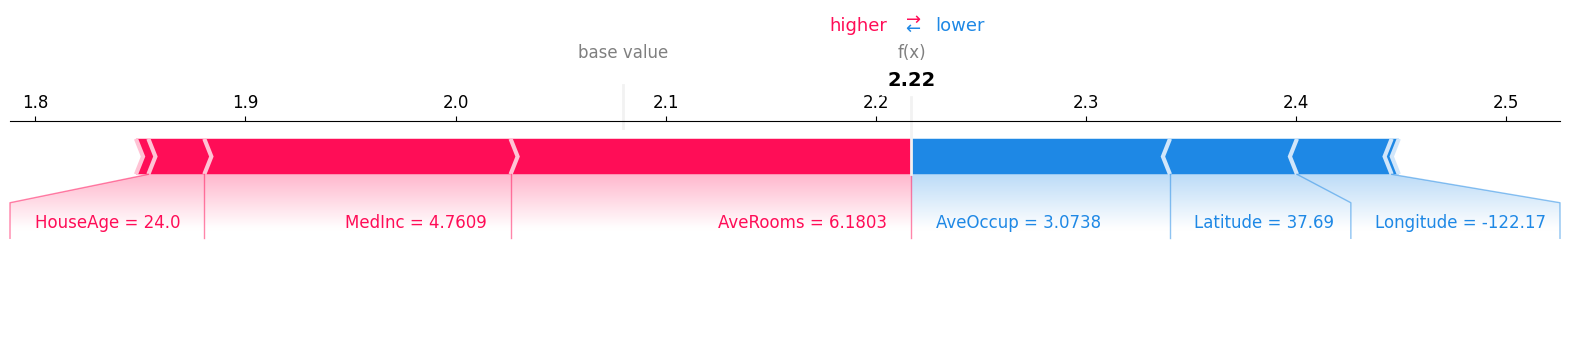

In [10]:
shap.plots.force(shap_values[observation_of_interest], matplotlib=True, show=True)

The average prediction for all houses in the dataset is shown as the *base value*, which is about 2.08. The prediction for this specific census block is 2.22, labeled as *f(x)*.

Features that increase the prediction relative to the base value are shown in red, while features that decrease the prediction are shown in blue. In this example, features such as `HouseAge`, `MedInc`, and `AveRooms` push the predicted house price upward, whereas `AveOccup`, `Latitude`, and `Longitude` decrease the prediction. The width of each arrow reflects the magnitude of the corresponding SHAP value, i.e. how strongly the feature contributes to the prediction. All feature contributions together add up to the difference between the base value and the final prediction. The feature names together with their corresponding feature values are displayed below the arrows.

You can find more advanced use cases for force plots [here](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/decision_plot.html).

#### Waterfall Plot

Another way to visualize explanations for individual predictions is the waterfall plot. Similar to the force plot, it shows how each feature contributes to moving the prediction away from the average model prediction toward the final output.

The plot starts with the *base value* and then sequentially adds the contribution of each feature. Features increasing the prediction are shown in red, while features decreasing the prediction are shown in blue. In contrast to the force plot, the waterfall plot displays the feature contributions explicitly as numerical values and orders them by their magnitude, making it easier to interpret the most influential features for a prediction.

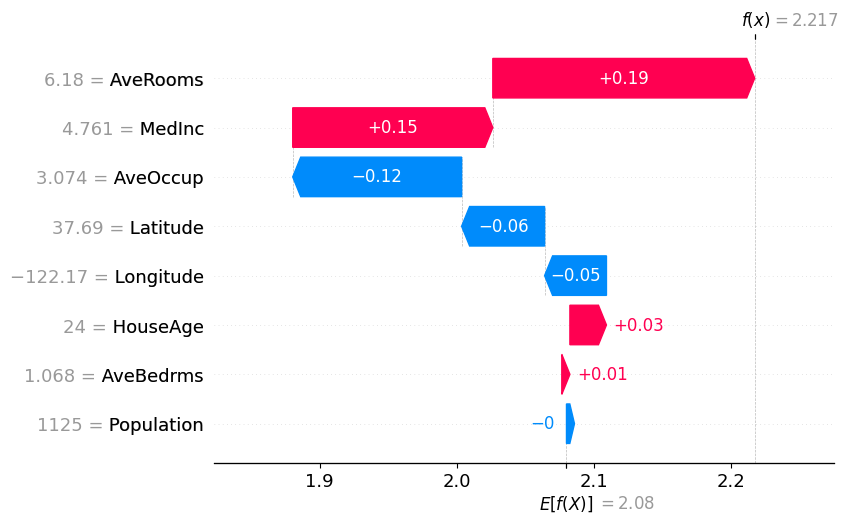

In [11]:
# get base_value as int (not list of int)
shap.plots.waterfall(shap_values[observation_of_interest])

The waterfall plot starts with the expected model output, shown at the bottom as (E[f(X)] = 2.08), and then sequentially adds the contribution of each feature until the final prediction (f(x) = 2.217) is reached. Features shown in red increase the predicted house price, while features shown in blue decrease it. The numbers displayed inside the bars correspond to the SHAP values, i.e. the contribution of each feature to the prediction relative to the average model output. The gray text on the left shows the actual feature values for this sample.

*Note: SHAP values are sometimes misinterpreted. A SHAP value does not represent the effect of removing a feature from model training. Instead, it estimates how much a feature contributes to moving the prediction away from the average prediction, given the current combination of feature values.*

### Global Explanations with SHAP

The local explanation plots are great for looking at the model's predictions with granularity. But what if we want a simple summary of how important each feature is in making predictions for the entire data set - something like *feature importance*?

While local SHAP explanations help us understand individual predictions, SHAP can also be used to analyze the overall behavior of a model across the complete dataset. By aggregating SHAP values over many samples, we can identify which features are most important globally and how different feature values influence the model predictions on average.

#### Global Bar Plots

SHAP provides global feature importance plots by aggregating the SHAP values over all samples. The most common approach is to compute the **mean absolute SHAP value** for each feature. Features with larger mean absolute SHAP values have a stronger overall influence on the model predictions and are therefore considered more important globally. Unlike local explanations, these plots summarize the average impact of each feature across the entire dataset.

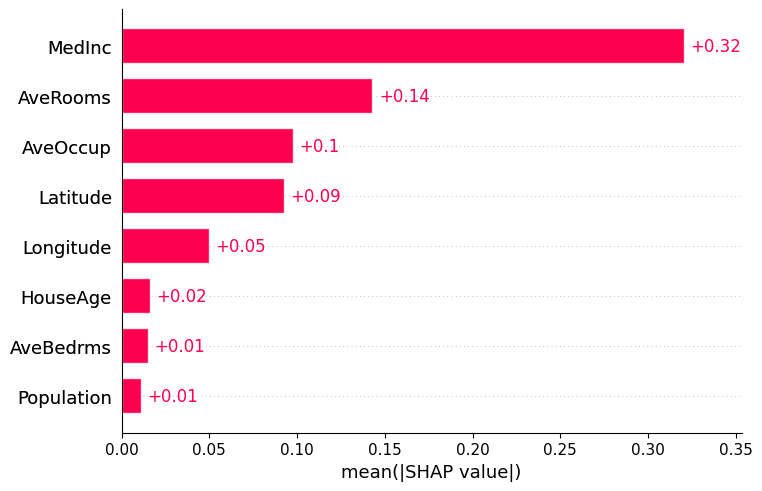

In [12]:
shap.plots.bar(shap_values)

The numbers beside each feature correspond to the **mean absolute SHAP values**, which are used as a measure of global feature importance. They are calculated by taking the absolute SHAP values for a feature across all samples and averaging them. Features with larger mean absolute SHAP values therefore have a stronger overall influence on the model predictions.

In this example, `MedInc` is by far the most important feature with an average absolute SHAP value of about 0.32, indicating that median income has the strongest overall effect on predicted house prices. `AveRooms`, `AveOccup`, and `Latitude` also contribute substantially to the model predictions, while features such as `AveBedrms` and `Population` have only a small overall influence.

Importantly, these global feature importances are derived directly from the local explanations of individual predictions. Each SHAP value describes the contribution of a feature for one specific sample, and the global importance is simply obtained by aggregating these local contributions across the complete dataset. This consistency between local and global explanations is one of the key strengths of SHAP and distinguishes it from many other interpretability methods.

The SHAP package also provides local bar plots, bar plots separated by cohorts or ordered by feature clustering. For more information on the different bar plots see [here](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html).

#### Beeswarm and Violin Plots

The SHAP package also provides more detailed global visualizations that show not only how important features are overall, but also how individual feature values influence the model predictions across the complete dataset.

Both beeswarm and violin plots display the distribution of SHAP values for each feature over all samples. This allows us to analyze not only the magnitude of feature importance, but also the direction, spread, and variability of feature effects. In addition, the color coding of the samples indicates whether high or low feature values are associated with higher or lower model predictions.

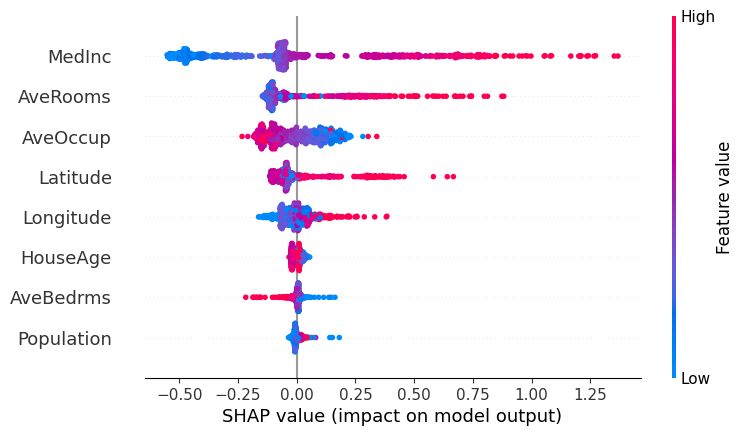

In [13]:
shap.plots.beeswarm(shap_values)

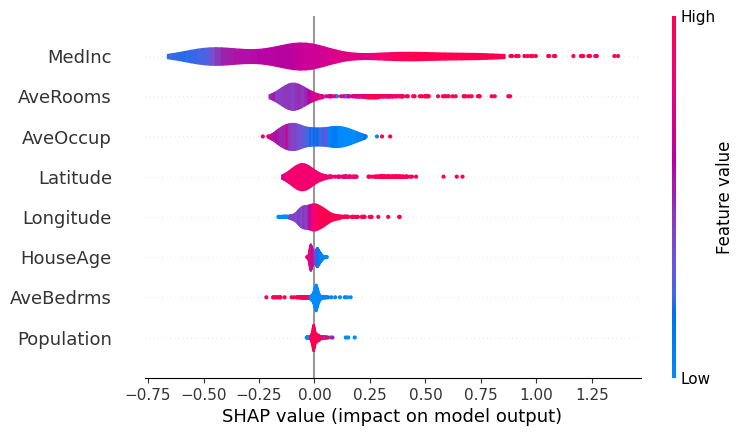

In [14]:
shap.plots.violin(shap_values)

The beeswarm plot provides an information-dense summary of how features influence the model predictions across the complete dataset. Each point represents the SHAP value of one sample for a given feature. The horizontal position indicates whether the feature increases or decreases the prediction, while the color represents the actual feature value from low (blue) to high (pink).

In this example, high values of `MedInc` strongly increase the predicted house prices, whereas low median incomes decrease the predictions. `MedInc` also shows the widest spread of SHAP values, confirming that it is the most influential feature overall. For `AveOccup`, we observe the opposite trend: low occupancy values tend to increase the predicted prices, while high occupancy values decrease them. Features such as `AveBedrms` and `Population` show only small SHAP value ranges and therefore have little influence on the predictions.

The violin plot summarizes the same information in a more compact distribution-based representation. Instead of displaying individual samples, it visualizes the density of SHAP values for each feature. Wider regions of the violin indicate ranges where many samples occur, while thinner regions correspond to less frequent SHAP values. This makes it easier to identify the spread, skewness, and variability of feature effects across the dataset.

Together, beeswarm and violin plots provide a more detailed view of global feature importance than simple bar plots, since they reveal not only how important features are overall, but also how feature values influence the direction and variability of model predictions.

#### Dependence Plots

Dependence plots show how the SHAP value of a feature changes with the actual feature value across the dataset. Each point represents one instance, where the x-axis shows the feature value and the y-axis shows the corresponding SHAP value, i.e. the contribution of that feature to the model prediction. This allows us to analyze how changes in a feature influence the model output and whether the relationship is linear, monotonic, or more complex. In addition, the points can be colored by a second, related feature. This can help reveal potential interaction effects, for example when the impact of one feature depends on the value of another feature.

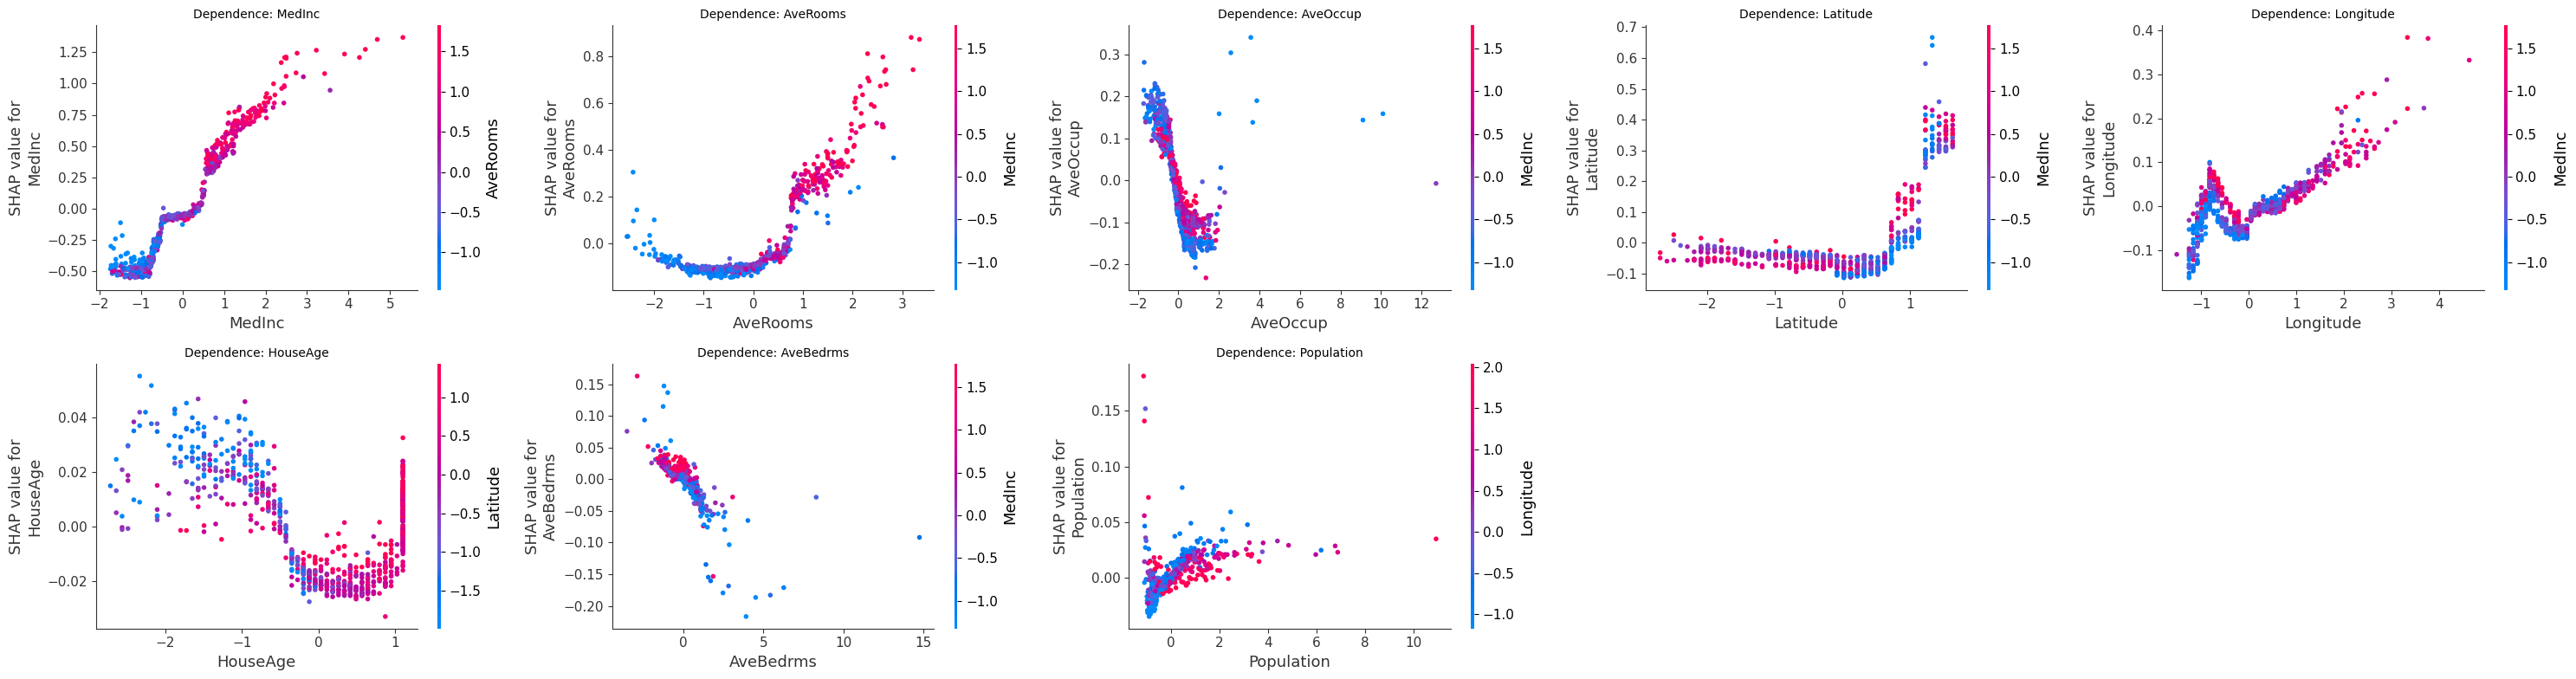

In [15]:
utils.plot_shap_dependence(shap_values, num_cols=5)

The dependence plots provide a more detailed view of how individual feature values influence the model predictions. Each point represents one sample, where the x-axis shows the feature value and the y-axis shows the corresponding SHAP value. The color indicates the value of a second, related feature and can reveal potential interaction effects.

Several clear relationships can be observed in these plots. `MedInc` shows a strong positive and almost monotonic relationship with the prediction: higher median incomes consistently increase the predicted house prices, while low incomes decrease them. A similar but weaker positive trend can be seen for `AveRooms`, where larger numbers of rooms lead to higher predictions. In contrast, `AveOccup` shows an inverse relationship. Higher occupancy values tend to reduce the predicted house prices, whereas low occupancy values increase the predictions. The `Latitude` and `Longitude` plots reveal strong non-linear geographic effects, indicating that the impact of location on house prices depends heavily on the spatial region. The plots also reveal potential feature interactions. For example, the `MedInc` dependence plot is colored by `AveRooms`, showing that high-income areas often also have larger houses. Similarly, the geographic features interact with `MedInc`, suggesting that the effect of location depends partly on the median income of the area.

Overall, the dependence plots complement the global importance plots by revealing not only which features are important, but also how feature values influence the prediction and whether these relationships are linear, non-linear, or dependent on interactions with other features.

--------

## Extra Material: SHAP for Multi-Class Classification

### The Wine dataset: Data and Model Loading

Let's use the wine quality dataset to see how SHAP can be used to explain multi-class classification models. The **Wine Recognition dataset** contains 178 wine samples from three different cultivators of wine in the same region in Italy. The wine was chemically analyzed and 13 different chemical attributes like *alcohol*, *malic acid*, *flavanoids* etc were measured. Our goal is to **classify wines** and find the most predictive features.

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/dataset_red_wine.jpg?raw=true" width="900" /></center>

<font size=1> Source:
[Link](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)

In the notebook [*Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb*](./Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb), we explain how to do the exploratory data analysis, preprocess the data and train a Random Forest model with the given data. The focus of this notebook lies on the interpretation of the previously trained model.

In [16]:
# Load and unpack the data
with open('../models/model_rf_wine.pickle', 'rb') as handle:
    data_and_model = pickle.load(handle)
    
X_train = data_and_model[0]
X_test = data_and_model[1]
y_train = data_and_model[2]
y_test = data_and_model[3]
model_wine = data_and_model[4]

X_train.head()

# is the model performing reasonably on the training data?
print(f'Model Performance on training data: {round(model_wine.score(X_train, y_train)*100,2)} % accuracy.')

# is the model performing reasonably on the test data?
print(f'Model Performance on test data: {round(model_wine.score(X_test, y_test)*100,2)} % accuracy.')

Model Performance on training data: 100.0 % accuracy.
Model Performance on test data: 97.22 % accuracy.


As we can see by the numbers above, our model performs perfectly on the training set and also generalizes great to the independent test set.

*Note: you should keep in mind that interpreting a low-performing model can lead to wrong conclusions.*

### SHAP Analysis

When using SHAP to explain a classifiers output, the default vaöue in TreeExplainer for `model_output="raw"`, which explains the raw output of the model. For regression models, "raw" is the standard output. For classification this is the log odds ratio. We can set the `model_output="probability"` explaining the output of the model transformed into probability space, i.e. SHAP values now sum to the probability output of the model. One major difference when analysing multi-class classification models with SHAP, compared to binary classification or regression models, is that we will get one shapley value matrix and expected value per class. Hence, in our case we will get three SHAP value matrices and expected values because we have three classes of wines. 

*Note: the order of the SHAP value matrices and expected value output is the same as the sorting of the target classes.*

In [17]:
# run SHAP
explainer = shap.TreeExplainer(model=model_wine, data=shap.maskers.Independent(X_train, max_samples=len(X_train)), model_output="probability")
shap_values = explainer(X_train)

In [18]:
# get original unscaled feature values
scaler = data_and_model[5]
X_train_unscaled = scaler.inverse_transform(X_train)
X_train_unscaled = pd.DataFrame(
    scaler.inverse_transform(X_train),
    columns=X_train.columns
).round(4)
shap_values.display_data = X_train_unscaled

For our multiclass classification task, shap explainer produces three expected values, corresponding to the average probability for each class, which is essentially the class frequency in the dataset.

In [19]:
# average prediction for the dataset
ev = explainer.expected_value
pm = np.mean(model_wine.predict_proba(X_train), axis=0)

print(f'Models average prediction for our data set is for class 0: {round(pm[0],3)}, for class 1: {round(pm[1],3)}, for class 2: {round(pm[2],3)}')
print(f'Expected value for our data set is for class 0: {round(ev[0],3)}, for class 1: {round(ev[1],3)}, for class 2: {round(ev[2],3)}')

Models average prediction for our data set is for class 0: 0.32, for class 1: 0.405, for class 2: 0.274
Expected value for our data set is for class 0: 0.32, for class 1: 0.405, for class 2: 0.274


### Local Explanations

Since we have three shapley value matrices, we will have to visualize the local explanations separately for each class.

In [20]:
observation_of_interest = 5
print(f'Class for observation of interest: {y_train[observation_of_interest]}; and models prediction for the observation of interest: {model_wine.predict(X_train)[observation_of_interest]}')

Class for observation of interest: type_2; and models prediction for the observation of interest: type_2


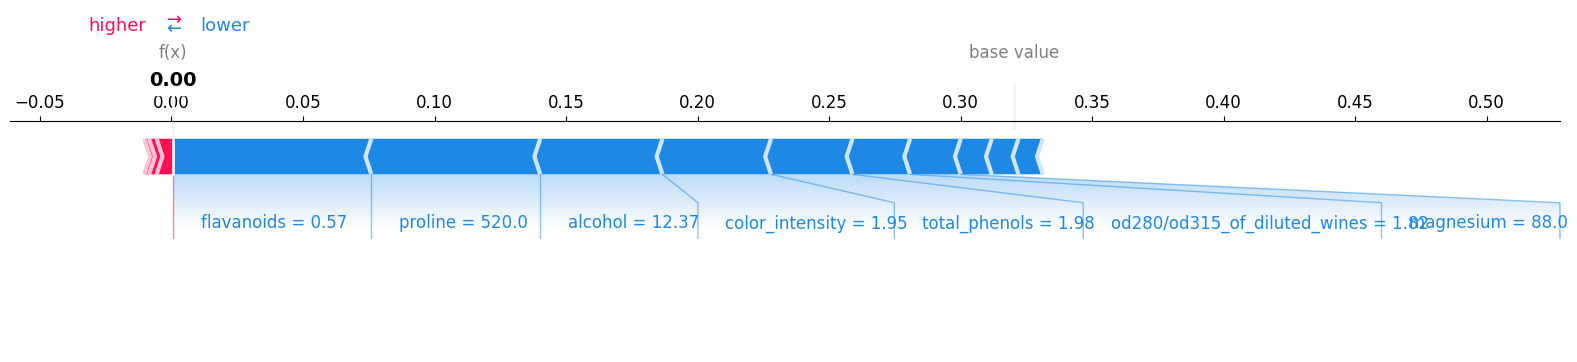

In [21]:
# force plot for class 0
target_class = 0
shap.plots.force(shap_values[observation_of_interest, :, target_class], matplotlib=True, show=True)

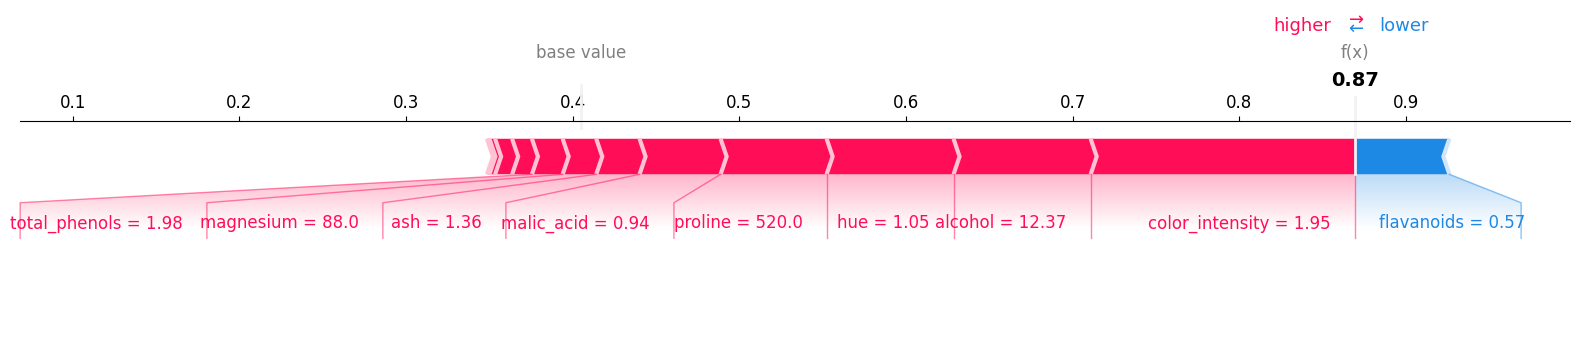

In [22]:
# force plot for class 1
target_class = 1
shap.plots.force(shap_values[observation_of_interest, :, target_class], matplotlib=True, show=True)

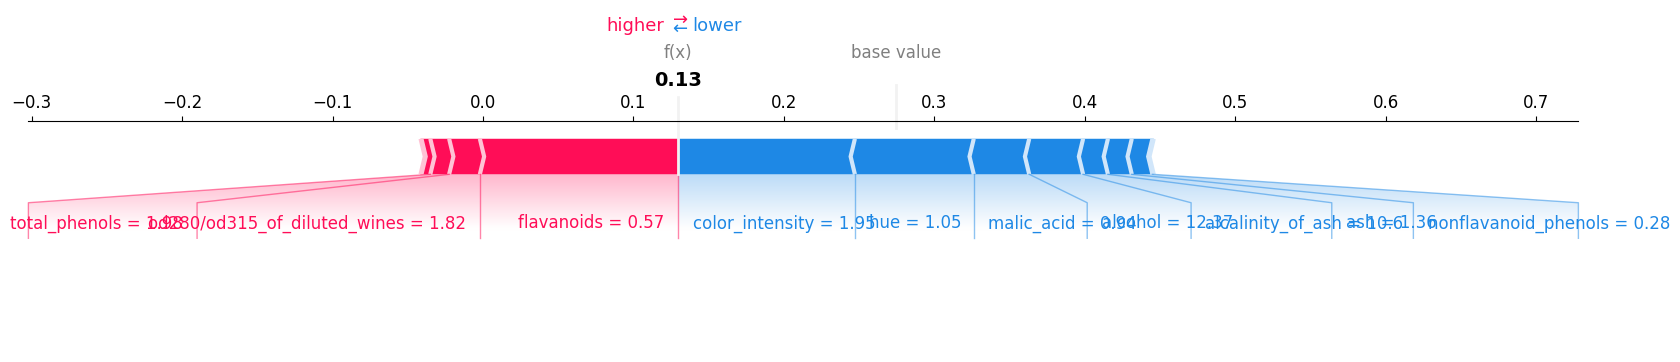

In [23]:
# force plot for class 2
target_class = 2
shap.plots.force(shap_values[observation_of_interest, :, target_class], matplotlib=True, show=True)

The average probability for each class is labeled as the *base value* in the respective plots (0.32 for type 1, 0.405, for type 2 and 0.27 for type 3). The predicted wine class probability for the observation of interest is labeled as the *f(x)*.

Comparing the three plots above, we can see that our observation of interest has a high probability of belonging to type 2 (probability = 0.87), while it has a low probability of belong to type 1 (probability = 0) or type 3 (probability = 0.13). 

Furthermore, we can see which feature contribute to a low or high class probability:
- type 1: the proline and flavanoids values highly lower the probability for this class
- type 2: the color intensity value highly increases the probability for this class
- type 3: the color intensity and hue value highly lowers the probability for this class

### Global Explanations

For the global explanations, we can visualize a combined bar plot that shows the average absolute SHAP values stacked per class.

*Note: the shap.plots.bar() function of the new package does currently not work for multi-class classification problems. Instead, we have to use the old shap.summary_plot() function.*

<Axes: xlabel='mean(|SHAP value|)'>

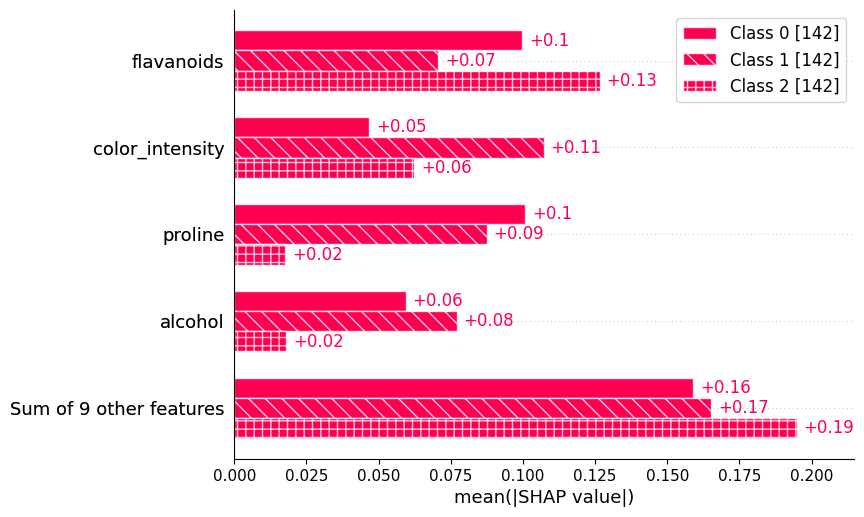

In [24]:
class_explanations = {
    "Class 0": shap_values[:, :, 0],
    "Class 1": shap_values[:, :, 1],
    "Class 2": shap_values[:, :, 2],
}

shap.plots.bar(class_explanations, max_display=5, show=False)

/var/folders/8g/7wdchs993770j0nbzbt5p0_r0000gn/T/ipykernel_16214/2757305634.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


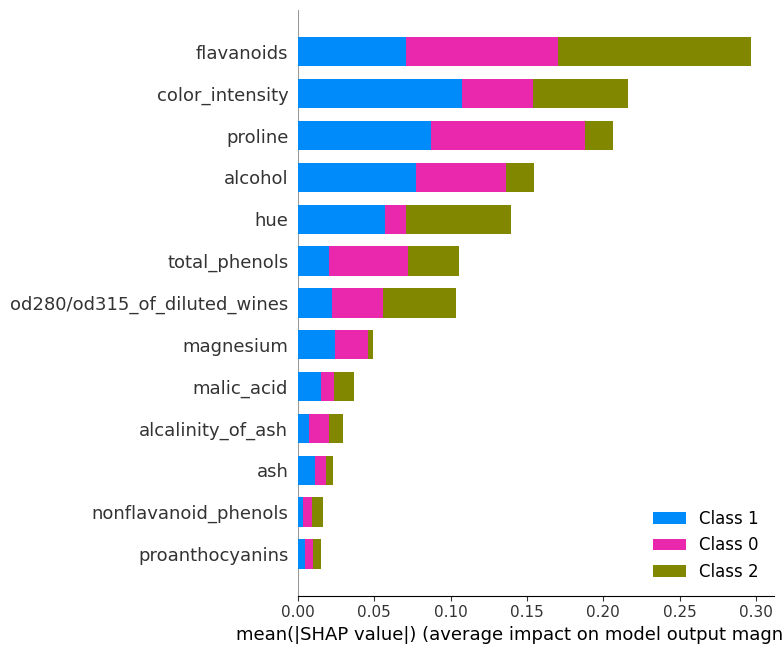

In [25]:
# using the legacy bar plot for better visualizations
explanation_old = shap.Explanation(
        values=list(np.transpose(shap_values.values,(2,0,1))),
        base_values=shap_values.base_values,
        data=X_train.round(4) ,
        feature_names=X_train.columns.tolist(),
    )

shap.summary_plot(
    explanation_old.values, 
    explanation_old.data, 
    plot_type='bar')

When we want to visualize the SHAP value summary as a beeswarm or violin plot, we have to do the visualization class-wise again.

*Note: the shap.plots.beeswarm() function of the new package does currently not work for multi-class classification problems. Instead, we have to use the old shap.summary_plot() function. For the violin plot, we have to manually select the dimension of interest.*

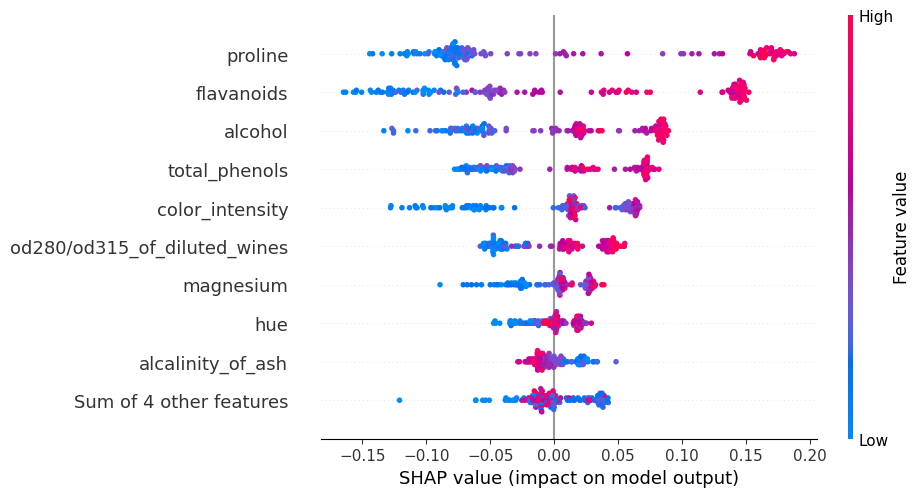

In [26]:
# summary plot for class 0
target_class = 0
shap.plots.beeswarm(shap_values[:, :, target_class], show=True)

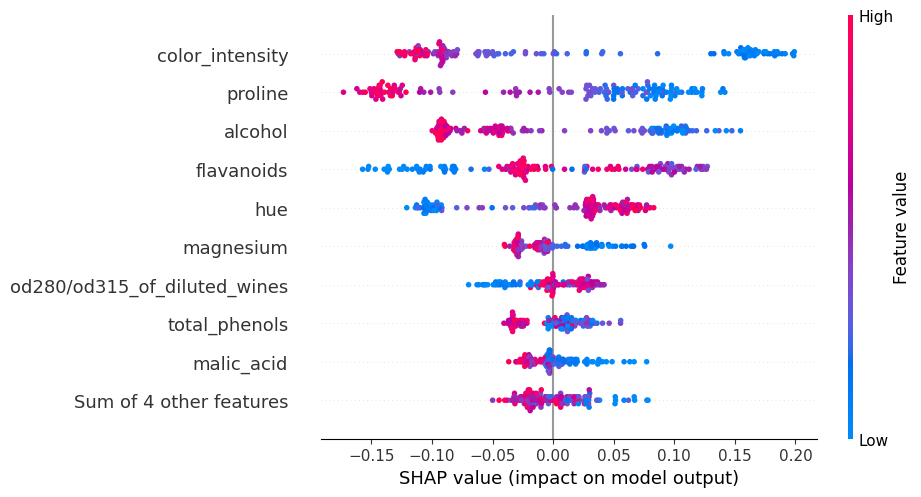

In [27]:
# summary plot for class 1
target_class = 1
shap.plots.beeswarm(shap_values[:, :, target_class], show=True)

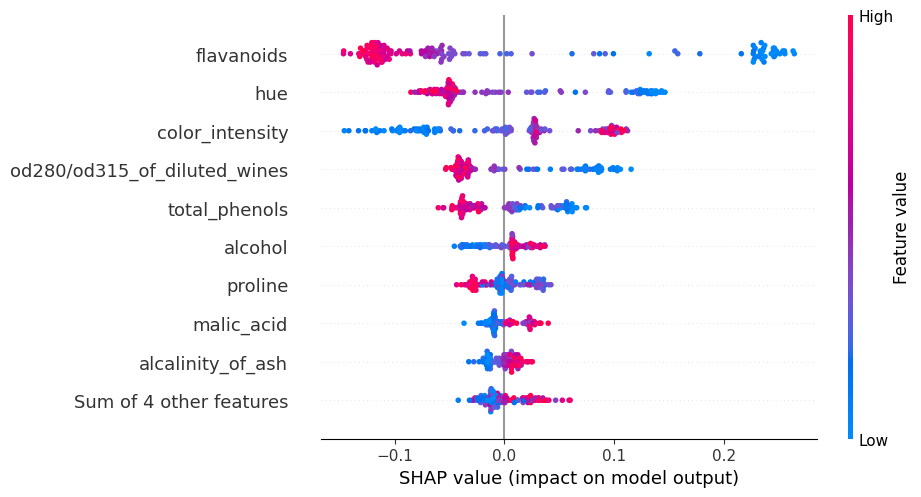

In [28]:
# summary plot for class 2
target_class = 2
shap.plots.beeswarm(shap_values[:, :, target_class], show=True)

From the plots above, we can see for instance that:

- high proline, flavanoids and alcohol values increase the probability for type 1 wines
- low color intensity, proline and alcohol values increases the probability for type 2 wines
- low flavanoids and hue but high color intensity values increase the probability for type 3 wines